# 3-Pulse Mach-Zehnder Interferometer with Temperature — New Pulse API

Replicates `mach_zehnder_with_temperature.ipynb` using the new event-based pulse sequence API
(`build_mach_zehnder_pulse_sequence` + `calculate_excited_fraction_for_pulse_sequence`).

Demonstrates a $\pi/2 - \pi - \pi/2$ Mach-Zehnder atom interferometer sequence.

Pulse phases: $0$, $\phi$, $4\phi$ respectively, with $\phi$ scanned from $0$ to $2\pi$.

Repeat with detunings drawn from a distribution based on a Maxwell-Boltzmann distribution of velocities at $T = 200\,\mathrm{nK}$.

A final comparison cell verifies numerical equivalence with the old low-level implementation.

In [1]:
import sys
sys.path.insert(0, '..')

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import constants

import lmt_sim.version_info as vs

from lmt_sim.lmt_sequence import (
    build_mach_zehnder_pulse_sequence,
    calculate_excited_fraction_for_pulse_sequence,
)
from lmt_sim.lmt_simulation import (
    RECOIL_FREQUENCY_HZ,
    RABI_FREQ,
)

%matplotlib inline

In [3]:
# np.random.seed(42)

T_FREE = 200e-6  # Free evolution time between pulses

MASS_ATOM = constants.atomic_mass * 87

# Draw velocities from 1D Maxwell-Boltzmann distribution at T
# 1D MB is a Gaussian with sigma_v = sqrt(k_B T / m)
N_ATOMS = 200
TEMPERATURE = 200e-9

sigma_v = np.sqrt(constants.k * TEMPERATURE / MASS_ATOM)
velocities = np.random.normal(0, sigma_v, size=N_ATOMS)
phi_values = np.linspace(0, 2 * np.pi, 101)

In [4]:
from tqdm import tqdm


def calc_mz_excitation_pulse_api(
    phi,
    initial_velocity_z=0.0,
    time_between_pulses=T_FREE,
):
    pulse_sequence = build_mach_zehnder_pulse_sequence(
        phi=phi,
        detuning_hz=RECOIL_FREQUENCY_HZ,
        time_between_pulses=time_between_pulses,
        rabi_frequency=RABI_FREQ,
        k=+1,
    )
    return calculate_excited_fraction_for_pulse_sequence(
        pulse_sequence,
        velocity=(0.0, 0.0, initial_velocity_z),
    )


# Simulate for each atom velocity
excitation_curves = np.empty((N_ATOMS, len(phi_values)))

for ind_atom, velocity in enumerate(tqdm(velocities, desc="Simulating atoms")):
    excitation_fractions = np.empty_like(phi_values)

    for ind_phi, phi in enumerate(phi_values):
        excitation_fractions[ind_phi] = calc_mz_excitation_pulse_api(
            phi,
            initial_velocity_z=velocity,
            time_between_pulses=T_FREE,
        )

        if excitation_fractions[ind_phi] < 0 or excitation_fractions[ind_phi] > 1:
            print(
                f"Warning: Unphysical excitation fraction {excitation_fractions[ind_phi]:.3f} "
                f"for velocity {velocity:.2f} m/s, phi={phi:.2f}"
            )

    excitation_curves[ind_atom, :] = excitation_fractions

mean_excitation = np.mean(excitation_curves, axis=0)
std_excitation = np.std(excitation_curves, axis=0)

Simulating atoms:   0%|          | 0/200 [00:00<?, ?it/s]

Simulating atoms:   1%|          | 2/200 [00:00<00:10, 19.14it/s]

Simulating atoms:   2%|▏         | 4/200 [00:00<00:10, 19.32it/s]

Simulating atoms:   4%|▎         | 7/200 [00:00<00:09, 20.25it/s]

Simulating atoms:   5%|▌         | 10/200 [00:00<00:09, 20.18it/s]

...

Simulating atoms:  95%|█████████▌| 190/200 [00:09<00:00, 21.19it/s]

Simulating atoms:  96%|█████████▋| 193/200 [00:09<00:00, 21.22it/s]

Simulating atoms:  98%|█████████▊| 196/200 [00:09<00:00, 21.60it/s]

Simulating atoms: 100%|█████████▉| 199/200 [00:09<00:00, 21.24it/s]

Simulating atoms: 100%|██████████| 200/200 [00:09<00:00, 20.67it/s]

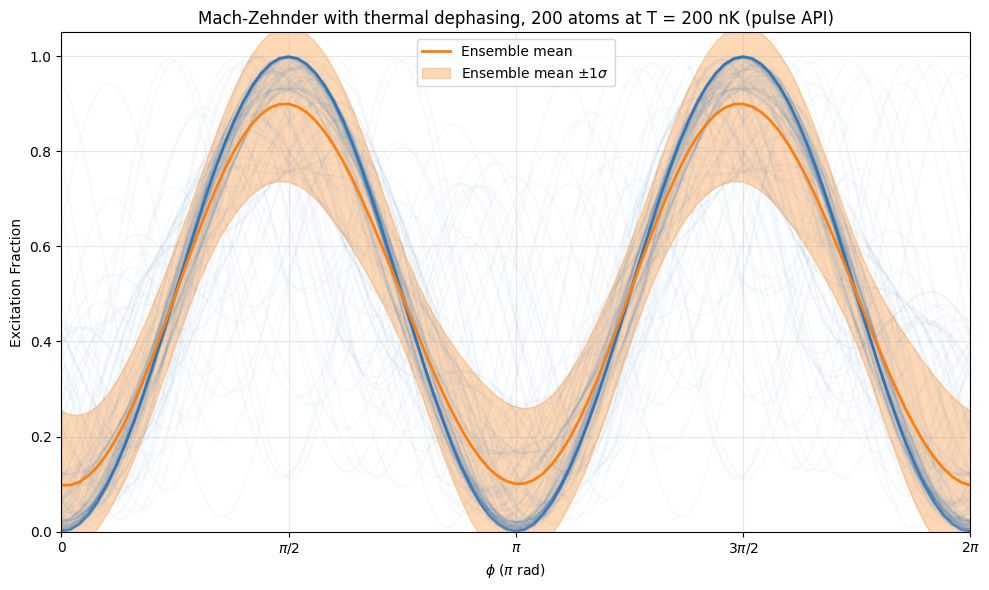

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))

# Plot individual traces with low alpha
for curve in excitation_curves:
    ax.plot(phi_values / np.pi, curve, color="tab:blue", alpha=0.03)

# Plot mean and std
ax.plot(
    phi_values / np.pi,
    mean_excitation,
    color="tab:orange",
    lw=2,
    label="Ensemble mean",
)
ax.fill_between(
    phi_values / np.pi,
    mean_excitation - std_excitation,
    mean_excitation + std_excitation,
    color="tab:orange",
    alpha=0.3,
    label=r"Ensemble mean $\pm 1\sigma$",
)

ax.set_xlabel(r"$\phi$ ($\pi$ rad)")
ax.set_ylabel("Excitation Fraction")
ax.set_title(
    f"Mach-Zehnder with thermal dephasing, {N_ATOMS} atoms at T = {TEMPERATURE*1e9:.0f} nK (pulse API)"
)
ax.set_xticks([0, 0.5, 1, 1.5, 2], ["0", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_xlim(0, 2)
ax.set_ylim(0, 1.05)
vs.tag_plot(small=True)
fig.tight_layout()

## Ensemble mean comparison

Run the same fixed-seed velocity ensemble through both the old low-level API and the new
pulse-sequence API and compare the resulting ensemble mean curves.
This is the meaningful test: any systematic difference between the two implementations
would survive the average and show up as a non-zero residual.

# Visualisations


## Simulated camera images

These synthetic camera images use the new event-based pulse-sequence API so each atom contributes weighted output branches with explicit final positions. The ground-state camera is read out immediately at the end of the sequence, while the excited-state camera is imaged after one additional 4 ms freefall.

The camera is displayed with $z$ vertical and $x$ horizontal. In this notebook the atoms start on-axis with no transverse velocity, so the horizontal extent is dominated by a lightweight synthetic point-spread function rather than real transverse cloud expansion.

The image color scale shows **density per pixel**, not total atom number. Because the excited-state image is taken after an extra 4 ms freefall, that cloud is more spread out, so it can look dimmer or broader even when it contains more atoms overall. To compare with the excitation-fraction curve, use the integrated ground and excited weights printed by the code cell below.

The camera rendering is intentionally lightweight and easy to retune later. If the number of simulated atoms changes, the main knobs to update are the imaging phase, delay, z bins, x bins, and optional PSF width in the code cell below.

Rendering camera shot:   0%|          | 0/200 [00:00<?, ?it/s]

Rendering camera shot: 100%|██████████| 200/200 [00:00<00:00, 2183.02it/s]

Camera phase:                     1.10pi rad
Camera-inferred excited fraction: 0.1680
Ensemble mean at nearest phase:   0.1680


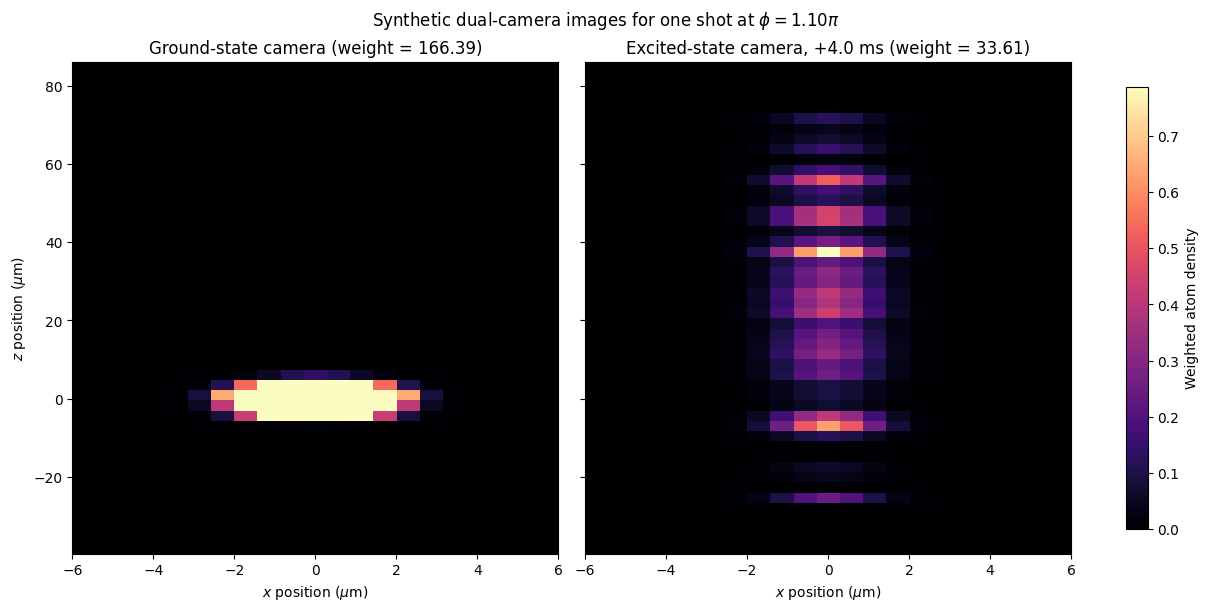

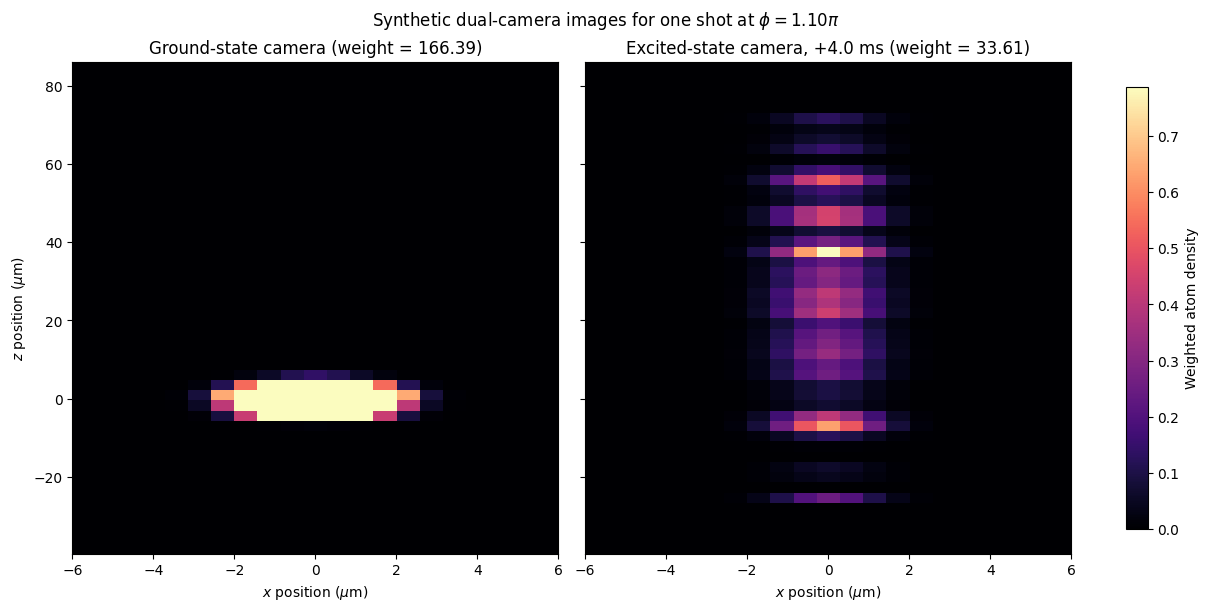

In [6]:
import numpy as np
from tqdm import tqdm

from lmt_sim.lmt_sequence import (
    build_mach_zehnder_pulse_sequence,
    run_pulse_sequence_in_lab_frame,
)
from lmt_sim.lmt_simulation import (
    RECOIL_FREQUENCY_HZ,
    RABI_FREQ,
    make_atom_states,
)
from lmt_sim.imaging import collect_branches, plot_camera_shot

CAMERA_PHASE = 1.1 * np.pi
CAMERA_EXCITED_DELAY = 4e-3  # excited camera reads out this long after the ground one

# Collect the ensemble's ground and excited output channels. The excited camera
# is read CAMERA_EXCITED_DELAY after the ground readout, so excited z advances
# ballistically by v_z * delay.
ground, excited = [], []
for v in tqdm(velocities, desc="Rendering camera shot"):
    sequence = build_mach_zehnder_pulse_sequence(
        phi=CAMERA_PHASE,
        detuning_hz=RECOIL_FREQUENCY_HZ,
        time_between_pulses=T_FREE,
        rabi_frequency=RABI_FREQ,
        k=+1,
    )
    state, _, _ = run_pulse_sequence_in_lab_frame(
        make_atom_states(initial_velocity_z=v, c0=1, c1=0),
        sequence,
        initial_velocity_z=v,
    )
    g, e = collect_branches(state)
    if len(e):
        e[:, 1] += e[:, 2] * CAMERA_EXCITED_DELAY
    ground.append(g)
    excited.append(e)

ground = np.vstack(ground)
excited = np.vstack(excited)

ground_total = ground[:, 3].sum()
excited_total = excited[:, 3].sum()
camera_excited_fraction = excited_total / (ground_total + excited_total)
ensemble_excited_fraction = mean_excitation[np.argmin(np.abs(phi_values - CAMERA_PHASE))]

print(f"Camera phase:                     {CAMERA_PHASE / np.pi:.2f}pi rad")
print(f"Camera-inferred excited fraction: {camera_excited_fraction:.4f}")
print(f"Ensemble mean at nearest phase:   {ensemble_excited_fraction:.4f}")

plot_camera_shot(
    ground, excited,
    ground_title=f"Ground-state camera (weight = {ground_total:.2f})",
    excited_title=f"Excited-state camera, +{1e3 * CAMERA_EXCITED_DELAY:.1f} ms (weight = {excited_total:.2f})",
    suptitle=f"Synthetic dual-camera images for one shot at $\\phi = {CAMERA_PHASE / np.pi:.2f}\\pi$",
)

## Filmstrip through the sequence

Same camera, but stepping through the sequence event by event. After each prefix `sequence[:i]` we re-image both the ground and excited cameras, so the panel shows how the wave packet splits and spreads through the three pulses. Each panel autoscales to its own peak; `w=` / `peak=` annotations make brightness comparable across panels.

`plot_mz_filmstrip(phi)` runs the whole thing for a chosen pulse phase; the cells below sweep it across a fringe.

In [7]:
from lmt_sim.imaging import plot_filmstrip


def plot_mz_filmstrip(phi):
    sequence = build_mach_zehnder_pulse_sequence(
        phi=phi,
        detuning_hz=RECOIL_FREQUENCY_HZ,
        time_between_pulses=T_FREE,
        rabi_frequency=RABI_FREQ,
        k=+1,
    )
    return plot_filmstrip(
        sequence, velocities,
        title=f"MZ filmstrip at $\\phi = {phi / np.pi:.3f}\\pi$ (each panel autoscaled)",
        desc=f"phi={phi / np.pi:.3f}pi",
    )

phi=0.000pi:   0%|          | 0/200 [00:00<?, ?it/s]

phi=0.000pi:  88%|████████▊ | 175/200 [00:00<00:00, 1746.17it/s]

phi=0.000pi: 100%|██████████| 200/200 [00:00<00:00, 1631.64it/s]

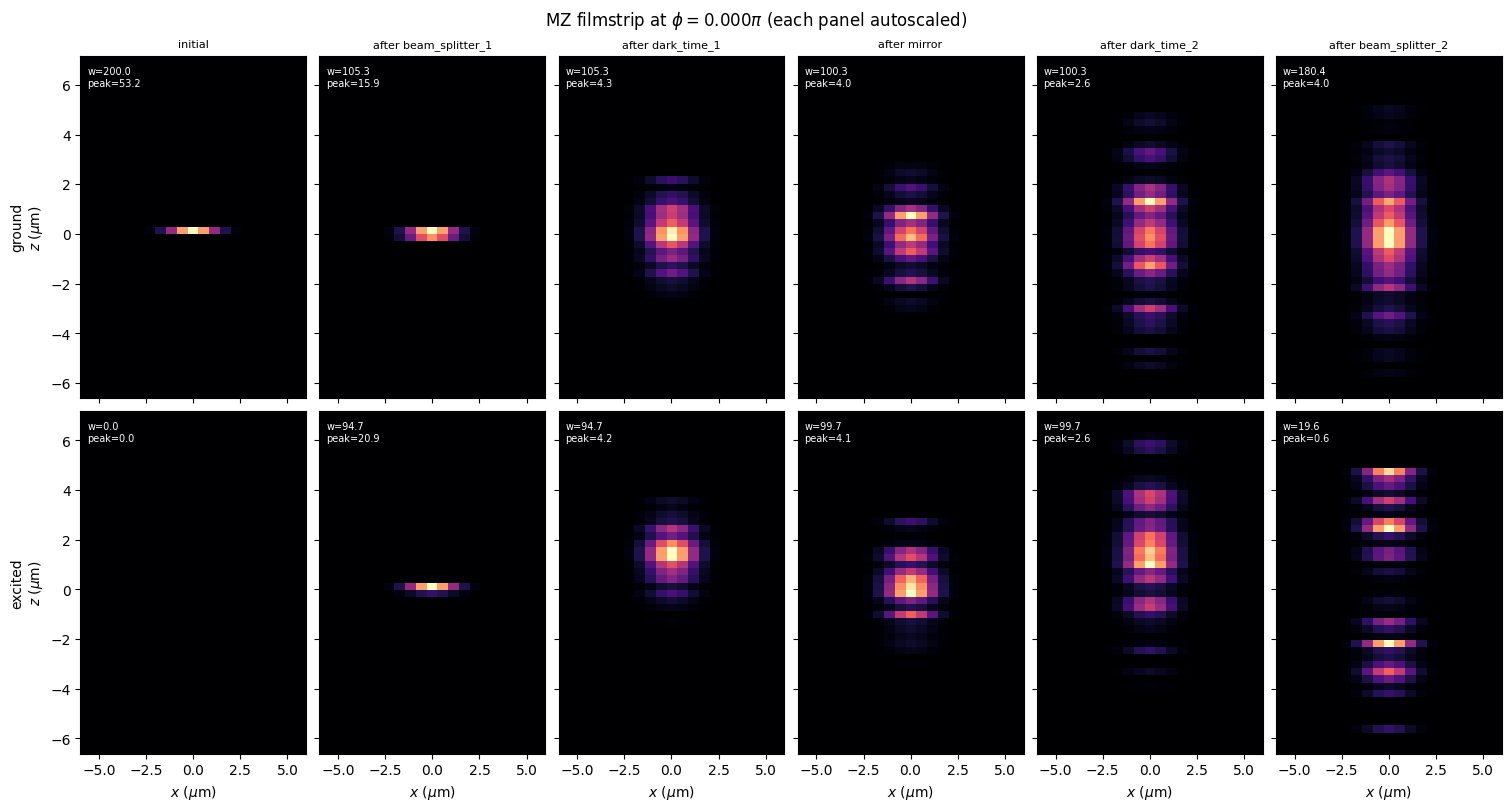

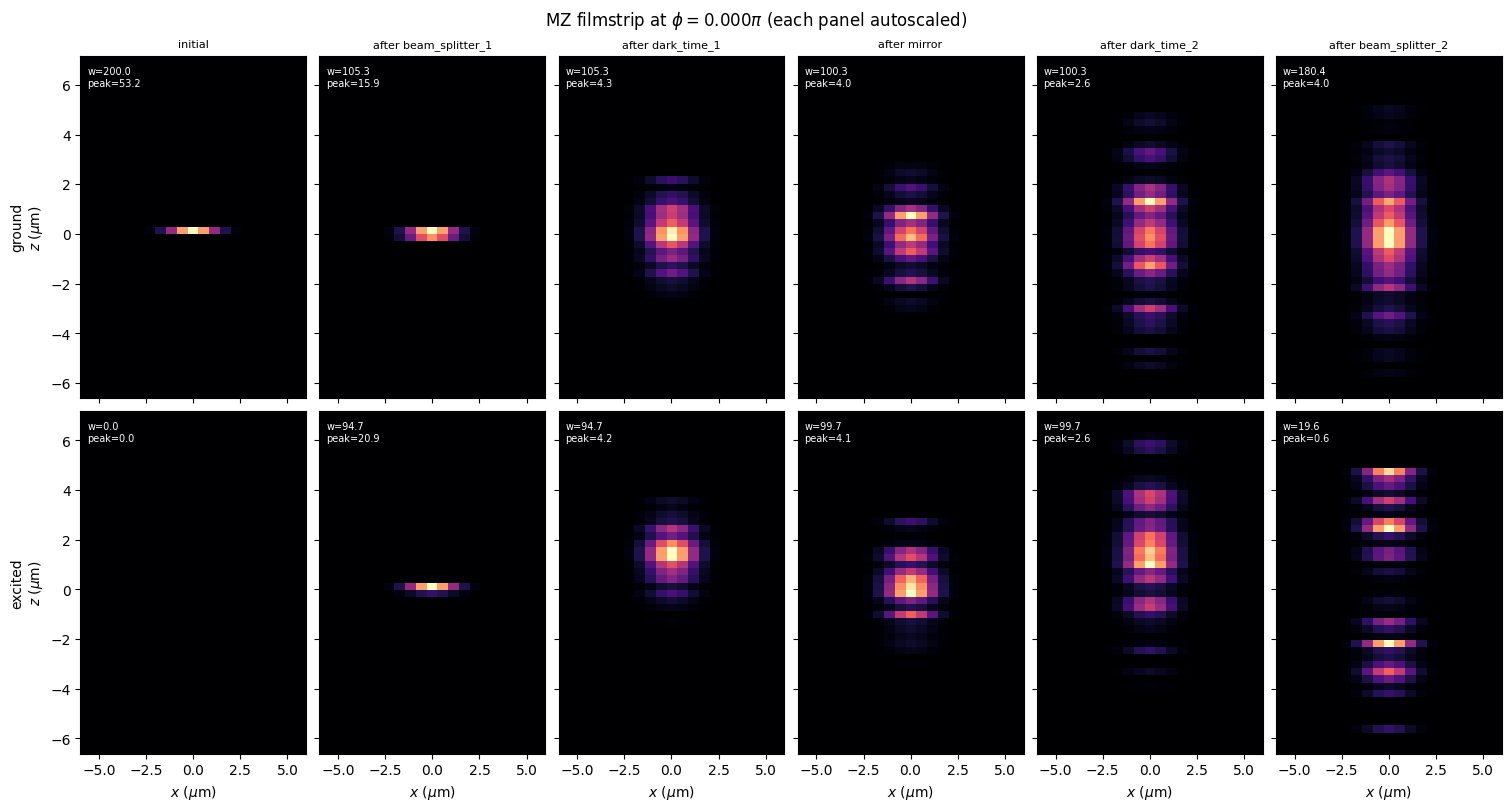

In [8]:
plot_mz_filmstrip(0.0)

phi=0.500pi:   0%|          | 0/200 [00:00<?, ?it/s]

phi=0.500pi:  80%|████████  | 161/200 [00:00<00:00, 1602.55it/s]

phi=0.500pi: 100%|██████████| 200/200 [00:00<00:00, 1473.18it/s]

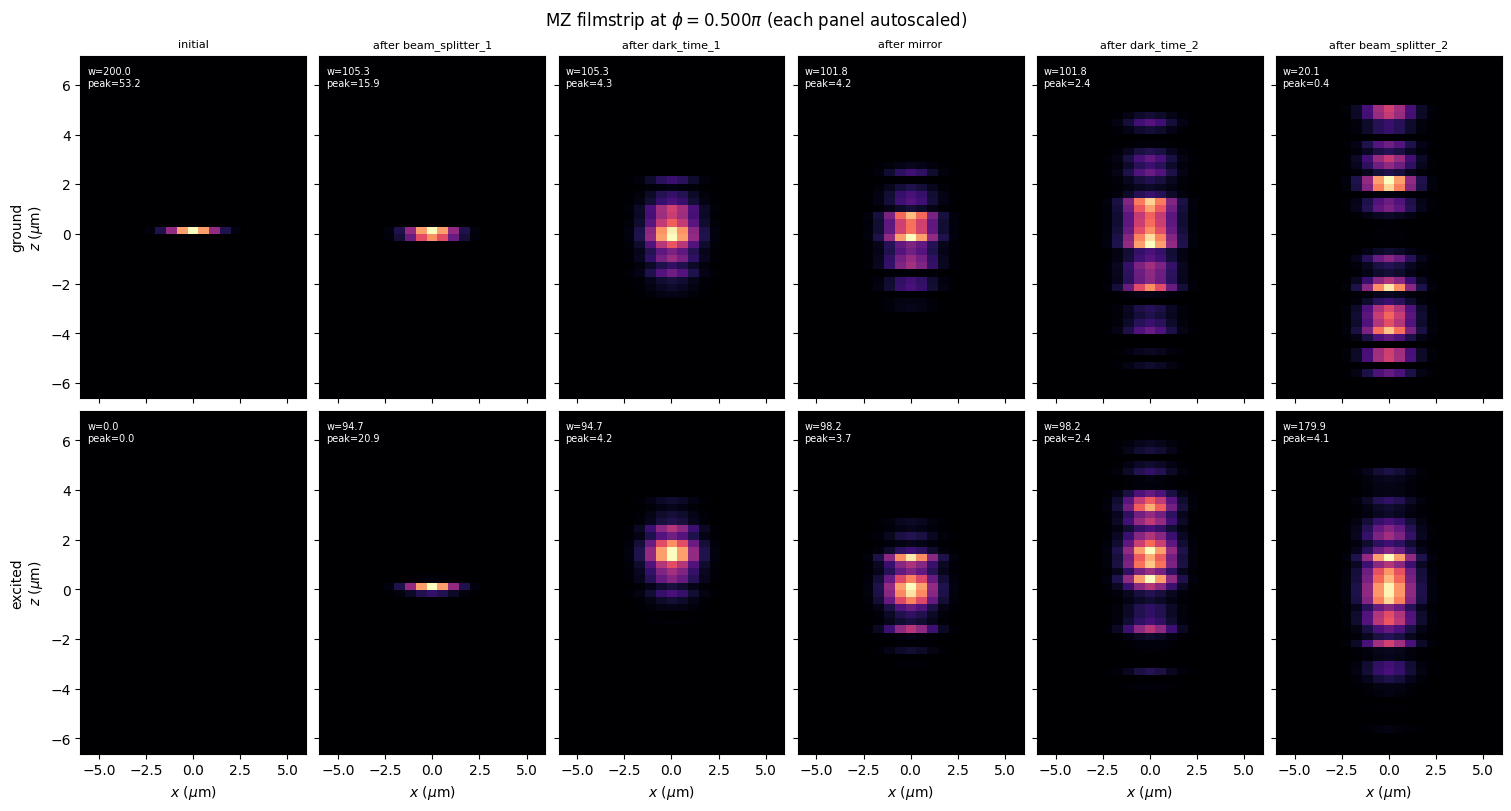

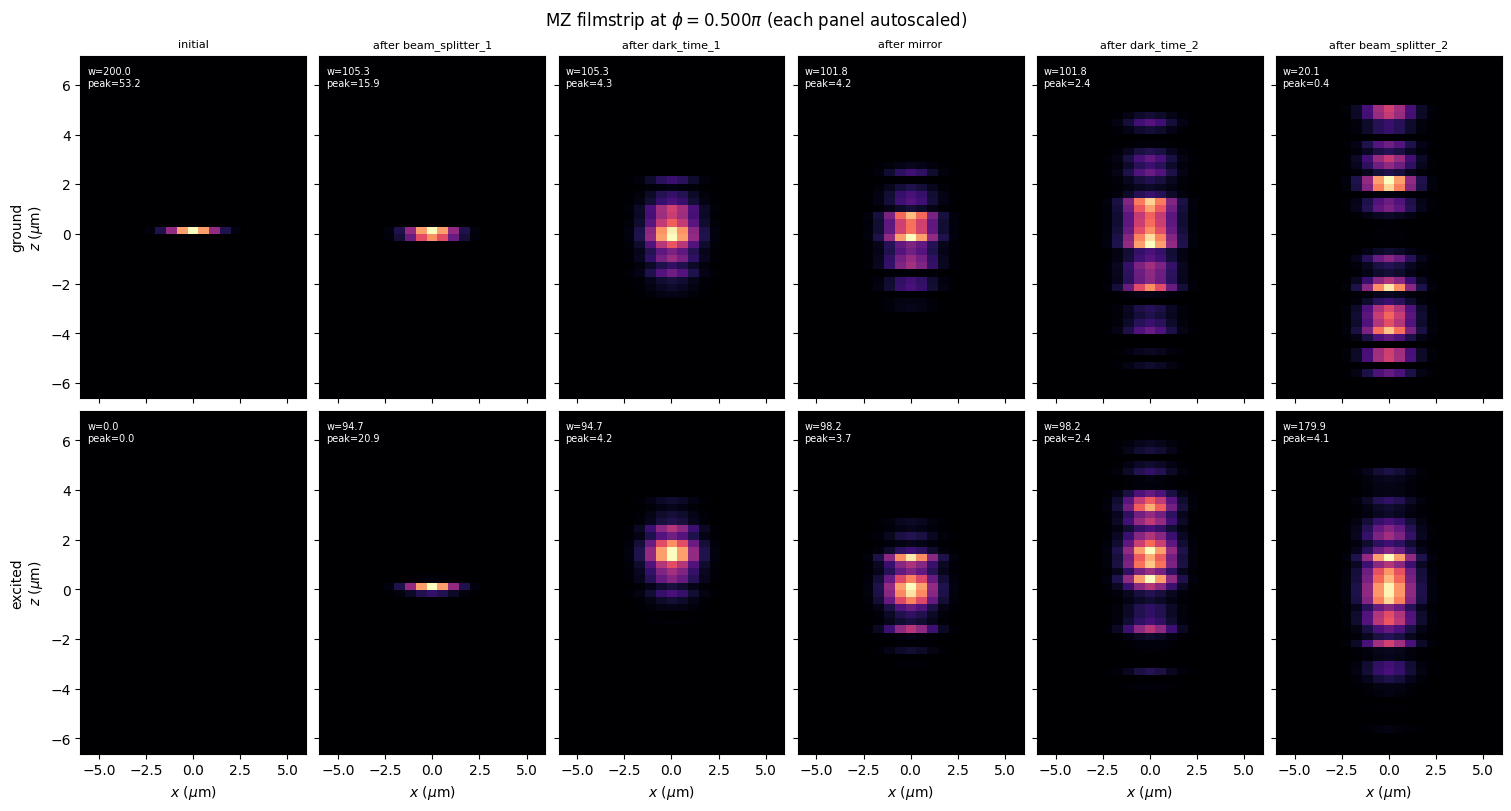

In [9]:
plot_mz_filmstrip(np.pi / 2)

phi=1.000pi:   0%|          | 0/200 [00:00<?, ?it/s]

phi=1.000pi:  80%|████████  | 161/200 [00:00<00:00, 1604.58it/s]

phi=1.000pi: 100%|██████████| 200/200 [00:00<00:00, 1505.76it/s]

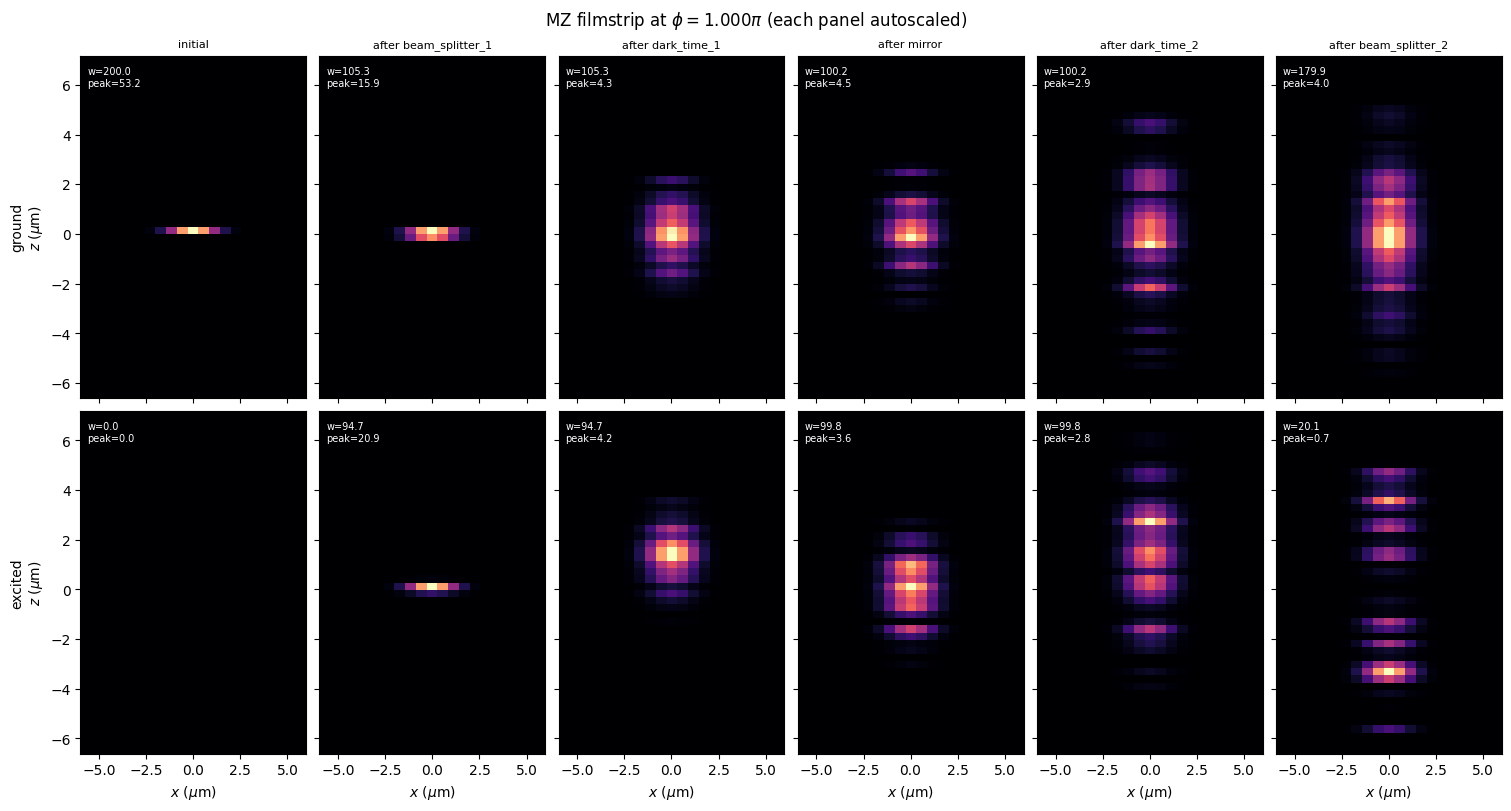

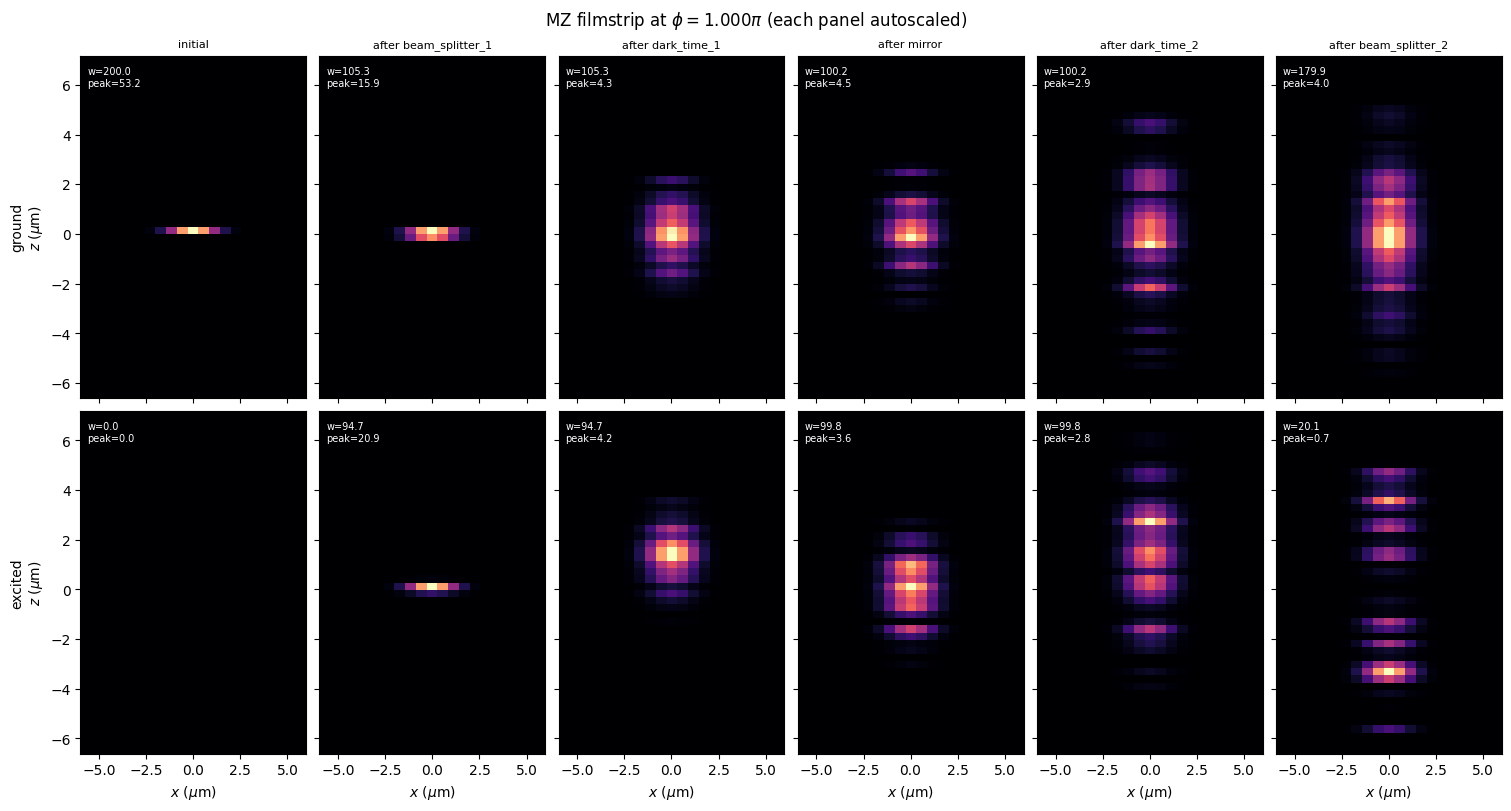

In [10]:
plot_mz_filmstrip(np.pi)

phi=1.500pi:   0%|          | 0/200 [00:00<?, ?it/s]

phi=1.500pi:  74%|███████▎  | 147/200 [00:00<00:00, 1465.33it/s]

phi=1.500pi: 100%|██████████| 200/200 [00:00<00:00, 1504.20it/s]

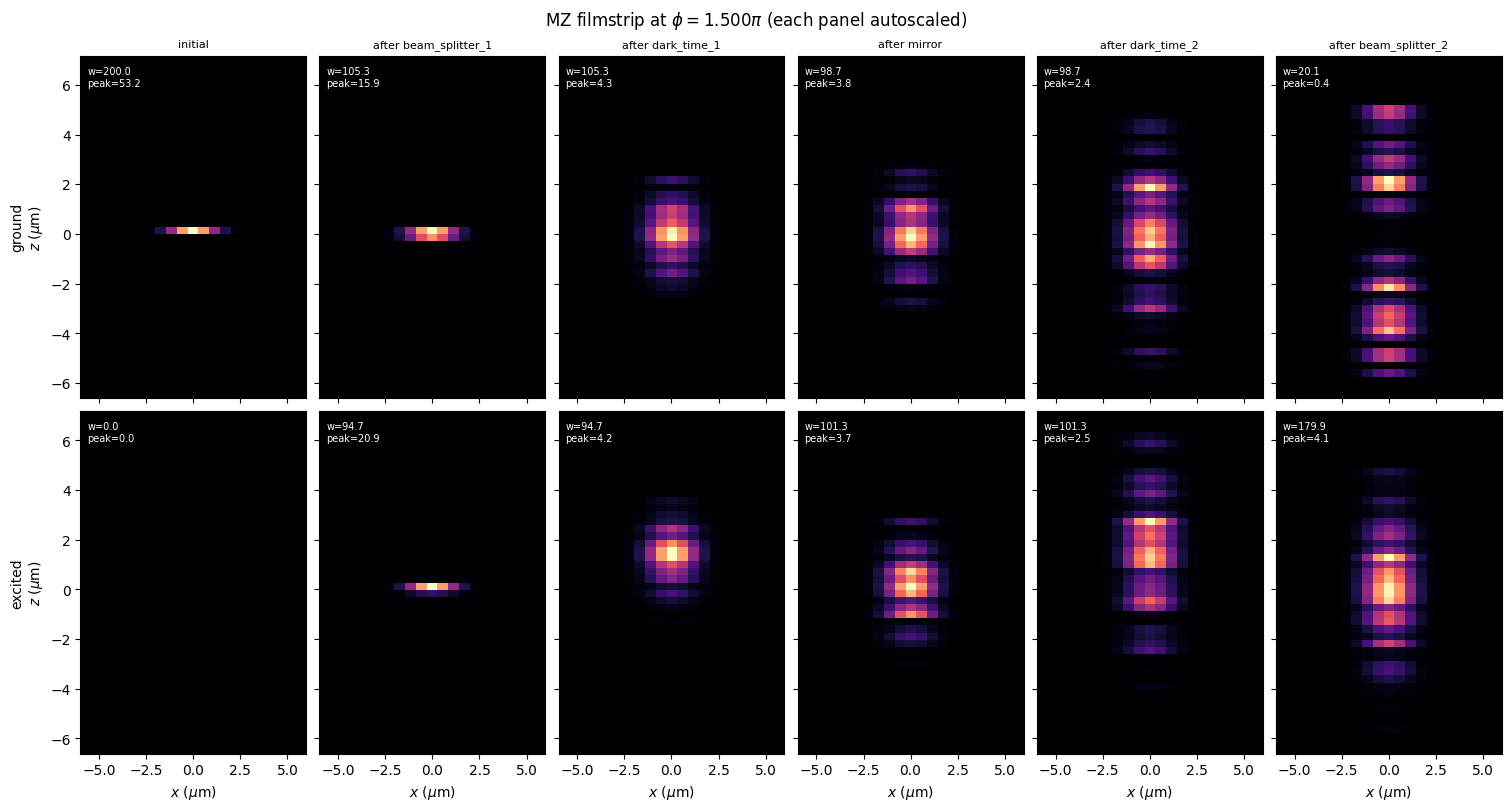

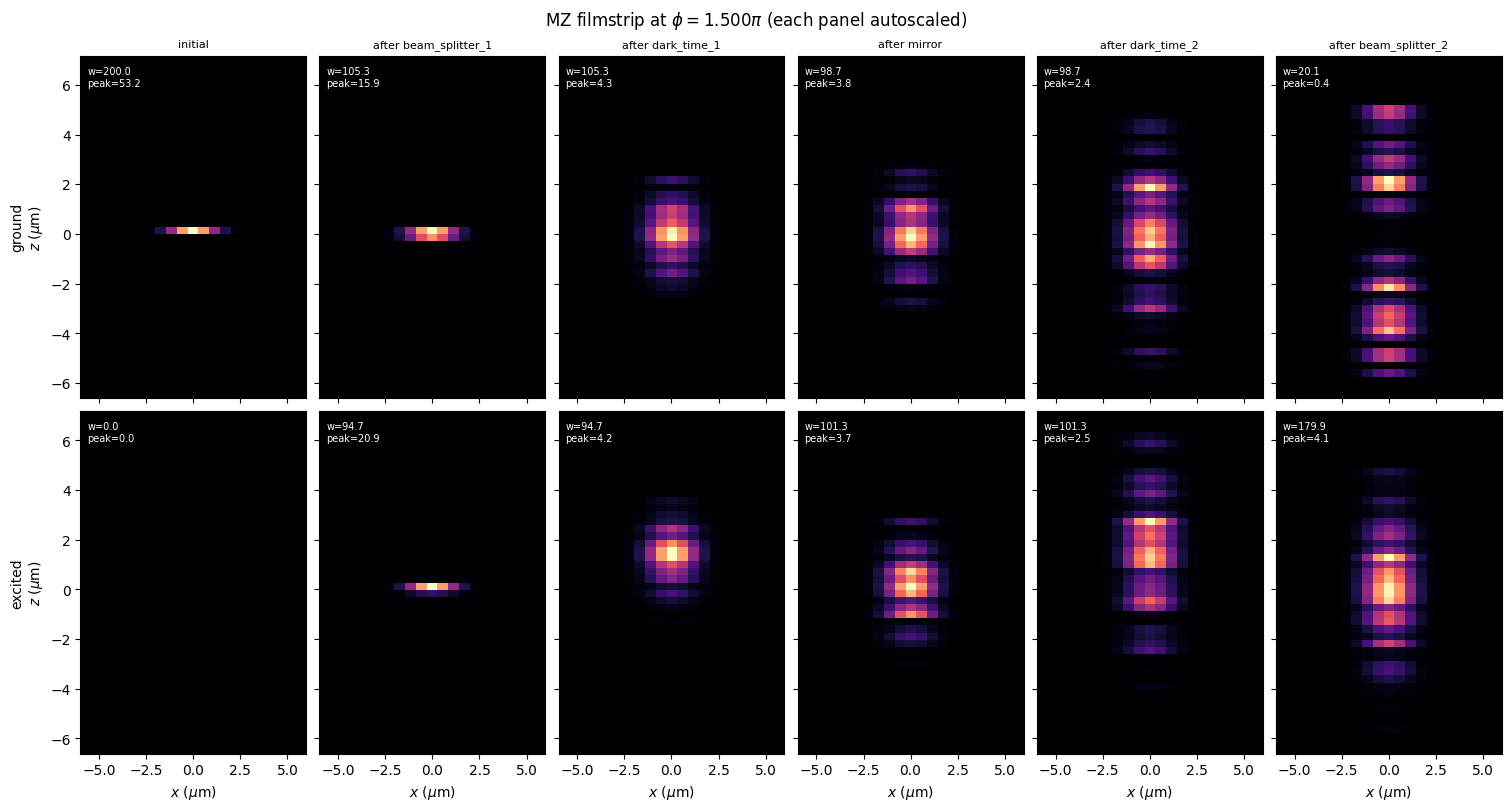

In [11]:
plot_mz_filmstrip(3 * np.pi / 2)

phi=2.000pi:   0%|          | 0/200 [00:00<?, ?it/s]

phi=2.000pi:  91%|█████████ | 182/200 [00:00<00:00, 1811.32it/s]

phi=2.000pi: 100%|██████████| 200/200 [00:00<00:00, 1710.46it/s]

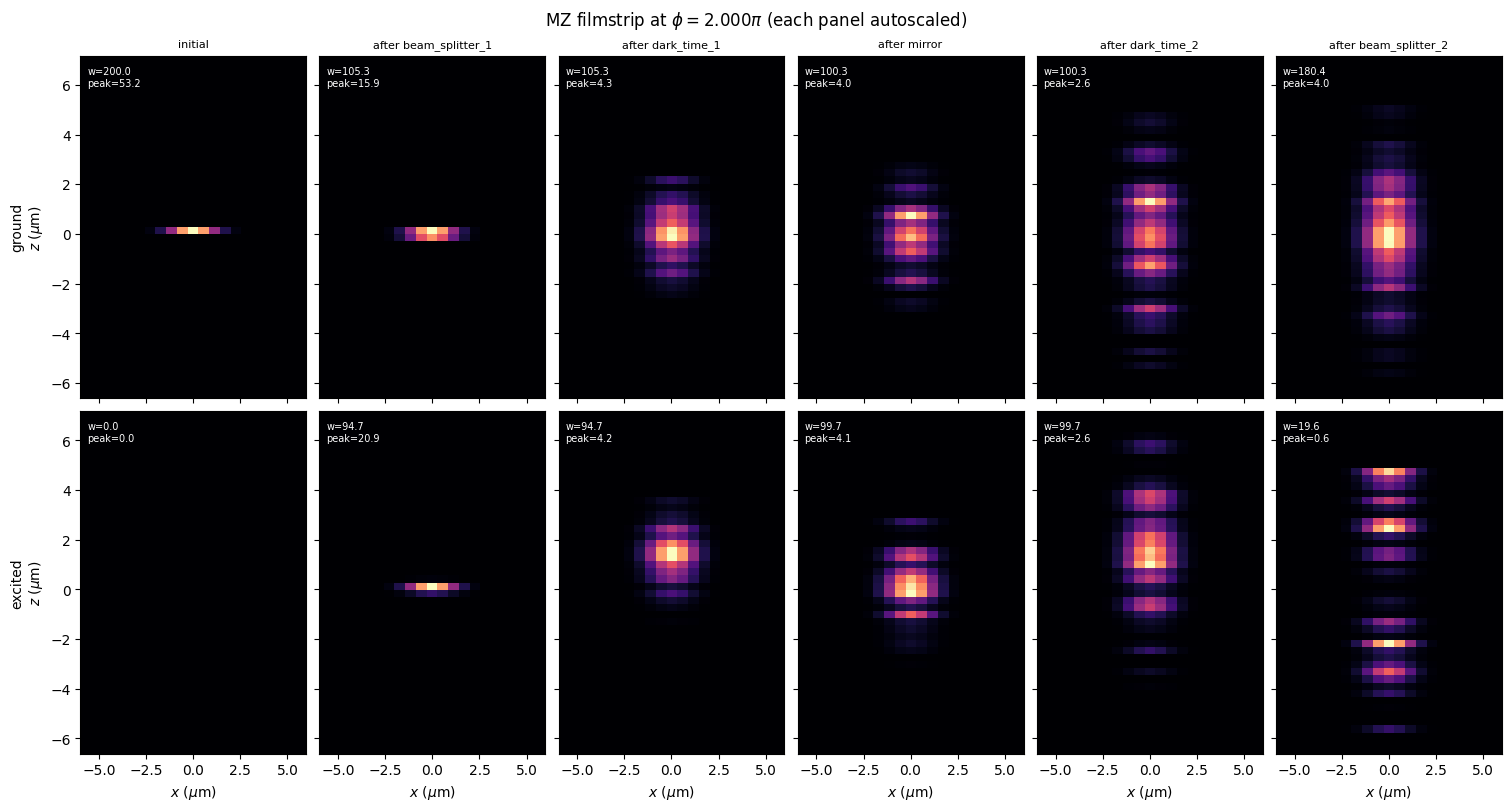

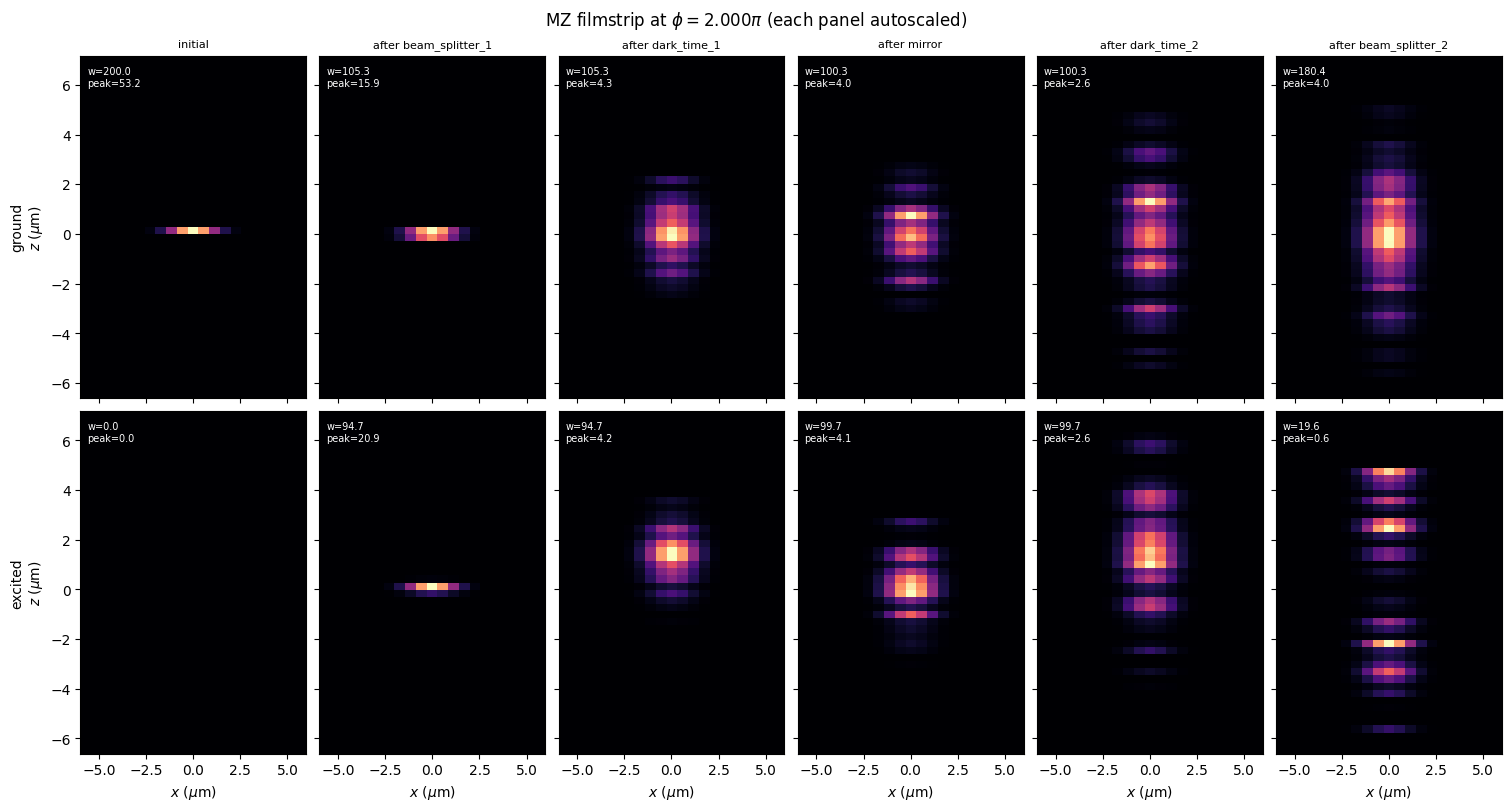

In [12]:
plot_mz_filmstrip(2 * np.pi)